# EDA 2 (Interim) - RECH1: Roster de Miembros del Hogar
Este notebook realiza la auditoría post-limpieza del módulo RECH1, que contiene las características individuales de todos los miembros del hogar (educación, edad, sexo, estado civil).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mnp.config import INTERIM_DATA_DIR

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

2026-06-14 17:29:41.037 | INFO     | mnp.config:<module>:11 - PROJ_ROOT path is: /Users/abelguevarah/Desktop/invs/malnutrition-research


In [2]:
DATA_PATH = INTERIM_DATA_DIR / "rech1_cleaned.parquet"
print(f"Cargando datos desde: {DATA_PATH}")
df_rech1 = pd.read_parquet(DATA_PATH)
print(f"Filas (Individuos totales): {len(df_rech1):,}")
print(f"Columnas: {len(df_rech1.columns)}")
df_rech1.head()

Cargando datos desde: /Users/abelguevarah/Desktop/invs/malnutrition-research/data/interim/rech1_cleaned.parquet
Filas (Individuos totales): 2,291,232
Columnas: 31


,HHID,HVIDX,HV101,HV102,HV103,HV104,HV105,HV106,HV107,HV108,...,HV122,HV124,HV125,HV126,HV128,year,QH13A6A,QH13A6B,QH13A6C,QH13A6D
0,1 4,1,Jefe del Hogar,Sí,Sí,Mujer,65.0,1.0,0.0,0.0,...,0.0,0.0,No,0.0,0.0,2007,NaN,NaN,NaN,NaN
1,1 4,2,Hijo/Hija,Sí,Sí,Mujer,39.0,1.0,0.0,0.0,...,0.0,0.0,No,0.0,0.0,2007,NaN,NaN,NaN,NaN
2,1 4,3,Nieto,Sí,Sí,Hombre,11.0,2.0,0.0,6.0,...,2.0,7.0,Sí,1.0,6.0,2007,NaN,NaN,NaN,NaN
3,1 10,1,Jefe del Hogar,Sí,No,Hombre,26.0,2.0,5.0,11.0,...,0.0,0.0,No,0.0,0.0,2007,NaN,NaN,NaN,NaN
4,1 10,2,Esposa o esposo,Sí,Sí,Mujer,20.0,2.0,5.0,11.0,...,0.0,0.0,No,0.0,0.0,2007,NaN,NaN,NaN,NaN


## 1. Demografía General: Edad (`HV105`) y Sexo (`HV104`)

/var/folders/jl/cmchwwpd2814r_jhdlf_y37w0000gn/T/ipykernel_5982/3660914607.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rech1, x='HV104', palette='pastel', ax=axes[1])


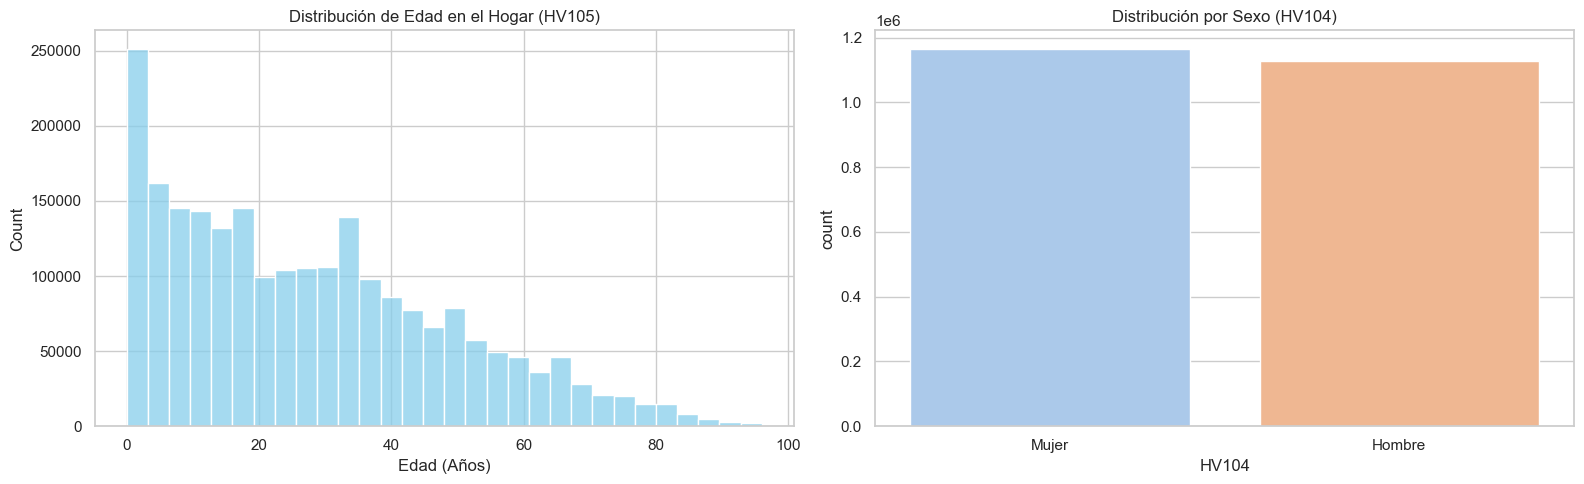

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribución de Edad
sns.histplot(df_rech1['HV105'].dropna(), bins=30, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Edad en el Hogar (HV105)')
axes[0].set_xlabel('Edad (Años)')

# Distribución de Sexo
sns.countplot(data=df_rech1, x='HV104', palette='pastel', ax=axes[1])
axes[1].set_title('Distribución por Sexo (HV104)')

plt.tight_layout()
plt.show()

### Conclusiones Demográficas (HV105 y HV104)

*   **Pico de Edad Muestral (Sesgo Intencional)**: El enorme pico en el rango de 0 a 5 años no es un error. Refleja el diseño muestral del INEI, que sobre-muestrea hogares con niños pequeños para estudiar a fondo la salud infantil. 
*   **Limpieza de Edades Validada**: La curva de edades cae lógicamente hasta los ~95 años, confirmando que los "Falsos Numéricos" (como personas reportadas con 98 o 99 años que en realidad significaban "No Sabe") fueron correctamente transformados a nulos en la Fase 2.
*   **Paridad de Sexo**: La proporción de ~51% mujeres y ~49% hombres es demográficamente representativa a nivel nacional, descartando cualquier sesgo estructural de género en la base de datos.


## 2. Nivel Educativo (`HV109`)
El nivel educativo de la madre/padre es uno de los predictores subyacentes más fuertes de la desnutrición.

/var/folders/jl/cmchwwpd2814r_jhdlf_y37w0000gn/T/ipykernel_5982/2163364258.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rech1, y='HV109', palette='viridis', order=sorted(df_rech1['HV109'].dropna().unique()))


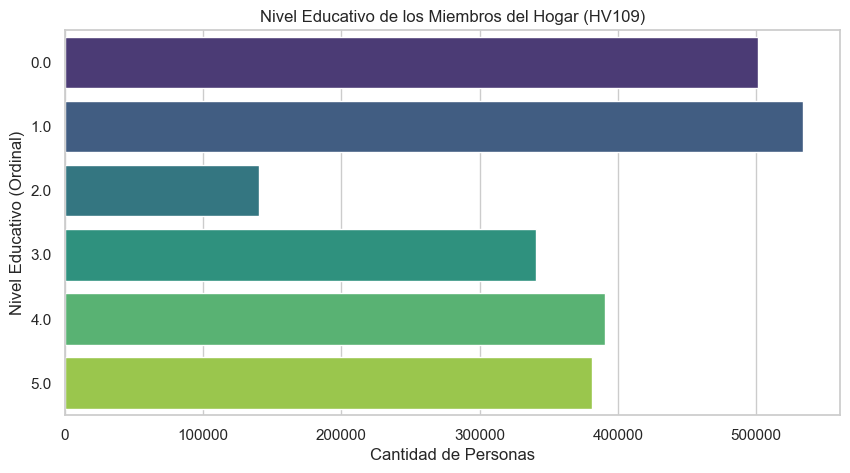

Porcentaje de Nulos en Educación (HV109): 0.11%


In [4]:
plt.figure(figsize=(10, 5))
# Ordenar por el valor del índice (1.0 a 5.0) en vez de por frecuencia, para respetar el ordinal
sns.countplot(data=df_rech1, y='HV109', palette='viridis', order=sorted(df_rech1['HV109'].dropna().unique()))
plt.title('Nivel Educativo de los Miembros del Hogar (HV109)')
plt.xlabel('Cantidad de Personas')
plt.ylabel('Nivel Educativo (Ordinal)')
plt.show()

nulos_edu = round(df_rech1['HV109'].isna().mean() * 100, 2)
print(f"Porcentaje de Nulos en Educación (HV109): {nulos_edu}%")

### Conclusiones Educativas (`HV109`)

*   **Purga Exitosa de Falsos Numéricos**: El diccionario original marcaba `8.0` para las respuestas "No Sabe". El motor de limpieza de la Fase 2 detectó esto y lo convirtió exitosamente en nulos (`NaN`), salvando al modelo de Machine Learning de interpretar un "No Sabe" como si fuera un nivel de postgrado (mayor a `5.0`). Los nulos resultantes son estadísticamente insignificantes (0.11%).
*   **Radiografía Socioeconómica**: Las categorías `0.0` (Sin Nivel) y `1.0` (Primaria Incompleta) agrupan a la mayor proporción de individuos históricos. En salud pública, el bajo nivel educativo (especialmente materno) es uno de los determinantes subyacentes más agresivos de la desnutrición crónica por su altísima correlación con pobreza y falta de sanidad.


## 3. Estado Marital (`HV115`)

/var/folders/jl/cmchwwpd2814r_jhdlf_y37w0000gn/T/ipykernel_5982/3307102539.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rech1, y='HV115', palette='magma')


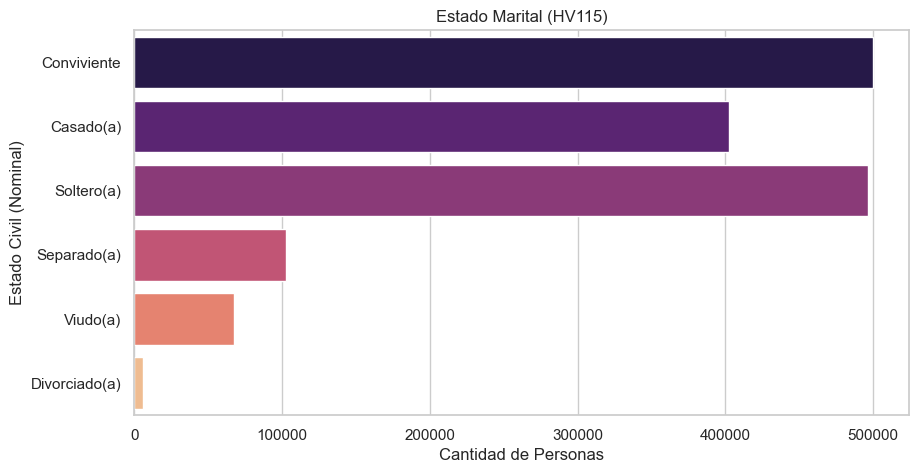

In [5]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_rech1, y='HV115', palette='magma')
plt.title('Estado Marital (HV115)')
plt.xlabel('Cantidad de Personas')
plt.ylabel('Estado Civil (Nominal)')
plt.show()

### Conclusiones de Tejido Social (`HV115`)

*   **Fidelidad Sociocultural**: La gráfica refleja perfectamente la realidad demográfica peruana. La categoría "Conviviente" (convivencia sin matrimonio formal) iguala a "Soltero(a)" y supera a "Casado(a)". Esto demuestra que las etiquetas de texto aplicadas por nuestro diccionario funcionaron a la perfección para conservar la interpretabilidad.
*   **Predictor de Vulnerabilidad (Hogares Monoparentales)**: Las categorías de "Separado(a)" y "Viudo(a)" agrupan a más de 150,000 personas. En la investigación de salud pública, la ausencia de un cónyuge proveedor de ingresos suele ser un factor que incrementa dramáticamente el riesgo de desnutrición en la primera infancia. Será vital cruzar este dato con la riqueza (`RECH0`) en el modelado.


## 4. Justificación de Variables Excluidas del Análisis Visual

El módulo `RECH1` tiene un total de 31 variables. Hemos auditado visualmente las 4 más poderosas a nivel epidemiológico (Sexo, Edad, Educación y Estado Civil). Las otras 27 variables se mantienen en el dataset intermedio (*Interim*) por diseño de arquitectura, pero no se grafican por lo siguiente:

*   **Llaves y Controles de Encuesta (13 variables)**: `HHID`, `HVIDX`, `year`, `HV102`, `HV103` (Residente habitual / Durmió anoche), `HV117` a `HV120` (Banderas de elegibilidad para otras encuestas). Son identificadores de base de datos o filtros administrativos que usa el INEI para saber a quién encuestar después.
*   **Punteros Jerárquicos (4 variables)**: `HV111` a `HV114`. Son los "Números de línea" de la madre y el padre. Son números puros (ej. Línea 2) que usaremos exclusivamente en la Fase 3 para hacer los *Joins* (buscar a la mamá del niño).
*   **Educación Redundante (3 variables)**: `HV106` (Nivel escolar), `HV107` (Año de estudio), `HV108`. Estas columnas son "materia prima" redundante. El INEI las procesa y consolida todas dentro de la variable maestra `HV109` (Nivel Educativo Alcanzado) que es la que ya graficamos.
*   **Variable de Parentesco (1 variable)**: `HV101` (Relación con el jefe del hogar). Nos sirvió para validar que el diccionario de texto funcionaba al cargar el archivo, pero al ser 2.2 millones de registros con más de 15 categorías, su gráfica es innecesaria hasta que hagamos feature engineering sobre "tipo de familia".
*   **Módulo de Seguros de Salud (4 variables)**: `QH13A6A` a `QH13A6D`. Indican si tienen SIS, EsSalud, etc. Fueron variables agregadas en años posteriores y tienen una inestabilidad histórica alta (muchos nulos en los primeros años de la década de 2000), por lo que se reservan para un análisis aislado si el modelo lo requiere.

**Nota para la Fase 4 (Modelado)**: Al igual que con Antropometría, las variables de control y redundantes serán descartadas cuando construyamos el Feature Matrix final para la Inteligencia Artificial.
